In [1]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import rasterio
import tifffile
import skimage
from matplotlib import pyplot as plt
from tqdm import tqdm
import cv2
import higra as hg
import torch
import pickle

In [2]:
# https://github.com/waldnerf/decode/blob/main/postprocessing/instance_segmentation.py
def watershed(input_hws, t_bound):
    # Create the directed graph
    size = input_hws.shape[:2]
    graph = hg.get_8_adjacency_graph(size)
    edge_weights = hg.weight_graph(
        graph,
        input_hws,
        hg.WeightFunction.mean)

    tree, altitudes = hg.watershed_hierarchy_by_dynamics(
        graph,
        edge_weights)
    
    # Get individual fields
    # by cutting the graph using altitude
    instances = hg.labelisation_horizontal_cut_from_threshold(
        tree,
        altitudes,
        threshold=t_bound).astype(float)
    return instances

In [3]:
import itertools
def compute_pair_to_iou_dict(masks):
    indices = np.arange(len(masks))
    pairs = itertools.combinations(indices, 2)
    pair_to_iou = {}
    for pair in pairs:
        i, j = pair
        pair_to_iou[tuple(pair)] = iou(masks[i], masks[j]).numpy()
    return pair_to_iou

def remove_duplicate_masks(indices, pair_to_iou, iou_threshold=0.95):
    for k in np.arange(1, len(indices)+1):
        for new_indices in itertools.combinations(indices, k):
            removed_indices = list(set(indices) - set(new_indices))
            valid_combination = True
            for i in removed_indices:
                new_indices_contain_similar_mask = False
                for j in new_indices:
                    if pair_to_iou[tuple(sorted((i, j)))] > iou_threshold:
                        new_indices_contain_similar_mask = True
                        break
                if not new_indices_contain_similar_mask:
                    valid_combination = False
                    break
            if valid_combination:
                return list(new_indices)

In [4]:
# https://stackoverflow.com/questions/66595055/fastest-way-of-computing-binary-mask-iou-with-numpy
def iou(mask1, mask2):
    intersection = (mask1 * mask2).sum()
    if intersection == 0:
        return 0.0
    union = torch.logical_or(mask1, mask2).to(torch.int).sum()
    return intersection / union

In [6]:
np.random.seed(0)

chips_df = pd.read_parquet('../data/ftw/france/chips_france.parquet', engine='pyarrow')
image_numbers_test = chips_df[chips_df['split']=='test']['aoi_id'].astype('string')
image_numbers = np.random.permutation(image_numbers_test)
image_numbers_calibration = image_numbers[:250]
image_numbers_test = image_numbers[250:350]

In [7]:
T_values = np.concatenate([np.arange(0.001, 0.01, 0.001), np.arange(0, 1.01, .01)])
print(T_values)

[0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009 0.    0.01  0.02
 0.03  0.04  0.05  0.06  0.07  0.08  0.09  0.1   0.11  0.12  0.13  0.14
 0.15  0.16  0.17  0.18  0.19  0.2   0.21  0.22  0.23  0.24  0.25  0.26
 0.27  0.28  0.29  0.3   0.31  0.32  0.33  0.34  0.35  0.36  0.37  0.38
 0.39  0.4   0.41  0.42  0.43  0.44  0.45  0.46  0.47  0.48  0.49  0.5
 0.51  0.52  0.53  0.54  0.55  0.56  0.57  0.58  0.59  0.6   0.61  0.62
 0.63  0.64  0.65  0.66  0.67  0.68  0.69  0.7   0.71  0.72  0.73  0.74
 0.75  0.76  0.77  0.78  0.79  0.8   0.81  0.82  0.83  0.84  0.85  0.86
 0.87  0.88  0.89  0.9   0.91  0.92  0.93  0.94  0.95  0.96  0.97  0.98
 0.99  1.   ]


# Visualizations

In [17]:
np.set_printoptions(legacy='1.25')

In [8]:
T_confidence_set = np.array([0.001, 0.003, 0.12,  0.31,  0.58 ])

In [9]:
q = 0.6960647702217102
tau = 0.7
alpha = 0.2

In [11]:
file = open('../data/ftw_predictions/france_test/conformal_ious_test_with_pairwise_IOUs_more_T_values.pkl', 'rb')
results_table_test = pickle.load(file)
file.close()

indices = np.arange(len(T_confidence_set))
IOU_threshold_duplicate_mask = 0.9
results_table_test["Final Mask Indices"] = results_table_test["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks(indices, x, iou_threshold=IOU_threshold_duplicate_mask))

results_table_test["Final Mask Number"] = results_table_test["Final Mask Indices"].apply(lambda x: len(x))
results_table_test["Final Mask IOUs"] = results_table_test.apply(lambda x: np.array(x["IOUs"])[x["Final Mask Indices"]], axis=1)
results_table_test["Final Mask max IOU"] = results_table_test["Final Mask IOUs"].map(lambda x: np.max(x))

In [14]:
np.random.seed(0)

confidence_sets_original = []
confidence_sets = []
for index, row in results_table_test.sample(n=5).sort_values(by='Final Mask Number', ascending=True).iterrows():
    image_number = row["image_number"]
    T_confidence_set_duplicates_removed = T_confidence_set[row["Final Mask Indices"]]
    
    pred_probability = rasterio.open(os.path.join('../data/ftw_predictions/france_test/predictions_3class/probability', image_number+'.tif')).read()[2]
    
    #print("Baseline Model Prediction")
    baseline_segmentation = watershed(pred_probability, 0.24)

    #print("Confidence Set (Original)")
    confidence_set = []
    for j, T in enumerate(T_confidence_set):
        pred_segmentation = watershed(pred_probability, T)
        confidence_set.append(pred_segmentation)
    confidence_sets_original.append(confidence_set)
    
    #print("Confidence Set (with Duplicates Removed)")
    confidence_set = []
    for j, T in enumerate(T_confidence_set_duplicates_removed):
        pred_segmentation = watershed(pred_probability, T)
        confidence_set.append(pred_segmentation)
    confidence_sets.append(confidence_set)

{(0, 1): array(1., dtype=float32), (0, 2): array(1., dtype=float32), (0, 3): array(1., dtype=float32), (0, 4): array(1., dtype=float32), (1, 2): array(1., dtype=float32), (1, 3): array(1., dtype=float32), (1, 4): array(1., dtype=float32), (2, 3): array(1., dtype=float32), (2, 4): array(1., dtype=float32), (3, 4): array(1., dtype=float32)}
g165_00065_7
MAX IOU: 0.9260615110397339
Final MAX IOU: 0.9260615110397339
{(0, 1): array(1., dtype=float32), (0, 2): array(0.9928058, dtype=float32), (0, 3): array(0.9928058, dtype=float32), (0, 4): array(0.9928058, dtype=float32), (1, 2): array(0.9928058, dtype=float32), (1, 3): array(0.9928058, dtype=float32), (1, 4): array(0.9928058, dtype=float32), (2, 3): array(1., dtype=float32), (2, 4): array(1., dtype=float32), (3, 4): array(1., dtype=float32)}
g165_00047_16
MAX IOU: 0.886956512928009
Final MAX IOU: 0.886956512928009
{(0, 1): array(0.29344434, dtype=float32), (0, 2): array(0.2189441, dtype=float32), (0, 3): array(0.21358243, dtype=float32), (

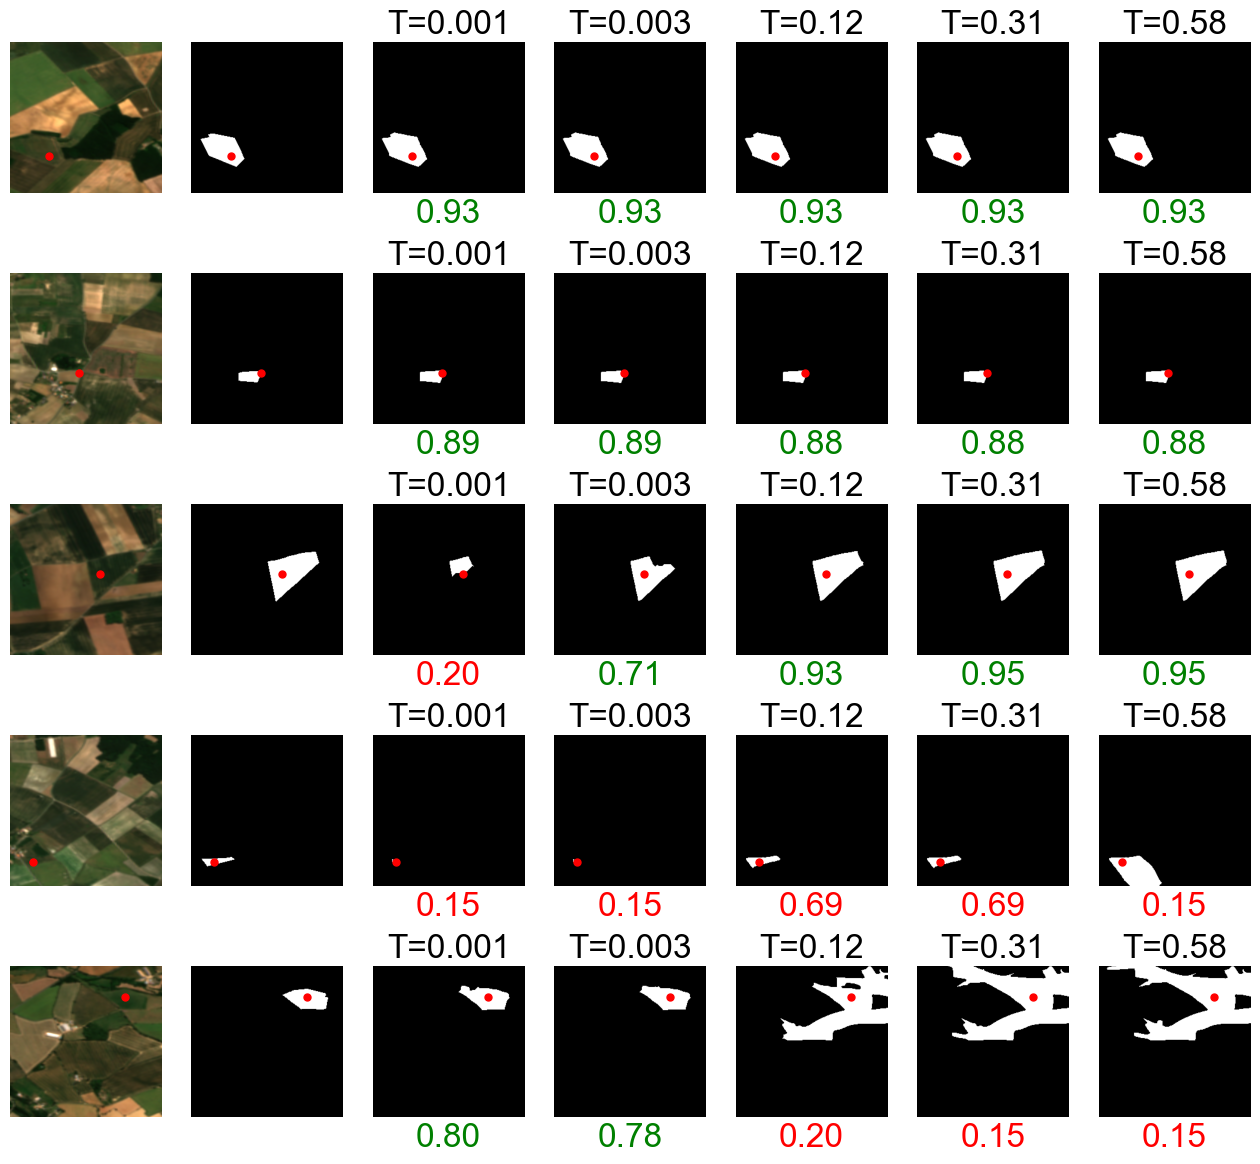

In [18]:
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24) 
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)
plt.rc('figure', titlesize=24)

from skimage.color import label2rgb
np.random.seed(0)

fig, axs = plt.subplots(nrows=5, ncols=7, figsize=(16, 14.5))

i=0
for index, row in results_table_test.sample(n=5).sort_values(by='Final Mask Number', ascending=True).iterrows():
    image_number = row["image_number"]
    coord = row["coord"]
    print(row['Pred Mask Pair to IOUs'])

    print(image_number)
    print("MAX IOU:", row["max IOU"])
    print("Final MAX IOU:", row["Final Mask max IOU"])

    rgb_img = rasterio.open(os.path.join('../data/ftw_predictions/france_test/inputs_stacked', image_number+'.tif')).read()
    rgb_img = rgb_img[0:3].transpose(1, 2, 0)/ 3000
    plt.sca(axs[i, 0])
    plt.imshow(np.clip(rgb_img, 0, 1))
    plt.plot(coord[1], coord[0], "o", color="red", markersize=5)
    plt.axis('off')

    #print("True Segmentation")
    true_segmentation = rasterio.open(os.path.join('../data/ftw/france/label_masks/instance', image_number+'.tif')).read()[0]
    plt.sca(axs[i, 1])
    plt.imshow(true_segmentation==true_segmentation[coord[0].item(), coord[1].item()], cmap='gray')
    plt.plot(coord[1], coord[0], "o", color="red", markersize=5)
    plt.axis('off')

    pred_probability = rasterio.open(os.path.join('../data/ftw_predictions/france_test/predictions_3class/probability', image_number+'.tif')).read()[2]
    
    #print("Confidence Set with Duplicates Removed")
    true_field = true_segmentation==true_segmentation[coord]
    for j, pred_segmentation in enumerate(confidence_sets_original[i]):
        pred_field = pred_segmentation==pred_segmentation[coord]
        IOU = iou(torch.from_numpy(true_field), torch.from_numpy(pred_field)).numpy().item()
        
        plt.sca(axs[i, 2+j])
        plt.imshow(pred_segmentation==pred_segmentation[coord[0].item(), coord[1].item()], cmap='gray')
        plt.plot(coord[1], coord[0], "o", color="red", markersize=5)
        
        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        if T_confidence_set[j] < 0.01:
            plt.title(f"T={T_confidence_set[j]:.3f}")
        else:
            plt.title(f"T={T_confidence_set[j]:.2f}")

        if IOU > tau:
            plt.xlabel(f"{np.round(IOU, 2):.2f}", color='green')
        else:
            plt.xlabel(f"{np.round(IOU, 2):.2f}", color='red')

    # remove empty grids
    for j in range(2+len(T_confidence_set), 7):
        axs[i, j].axis('off')

    i+= 1
    
#plt.tight_layout()
plt.show()

g165_00065_7
MAX IOU: 0.9260615110397339
Final MAX IOU: 0.9260615110397339
g165_00047_16
MAX IOU: 0.886956512928009
Final MAX IOU: 0.886956512928009
g212_00054_15
MAX IOU: 0.9471971988677979
Final MAX IOU: 0.9296835660934448
g165_00008_13
MAX IOU: 0.6934189200401306
Final MAX IOU: 0.6934189200401306
g165_00098_9
MAX IOU: 0.8005260825157166
Final MAX IOU: 0.8005260825157166


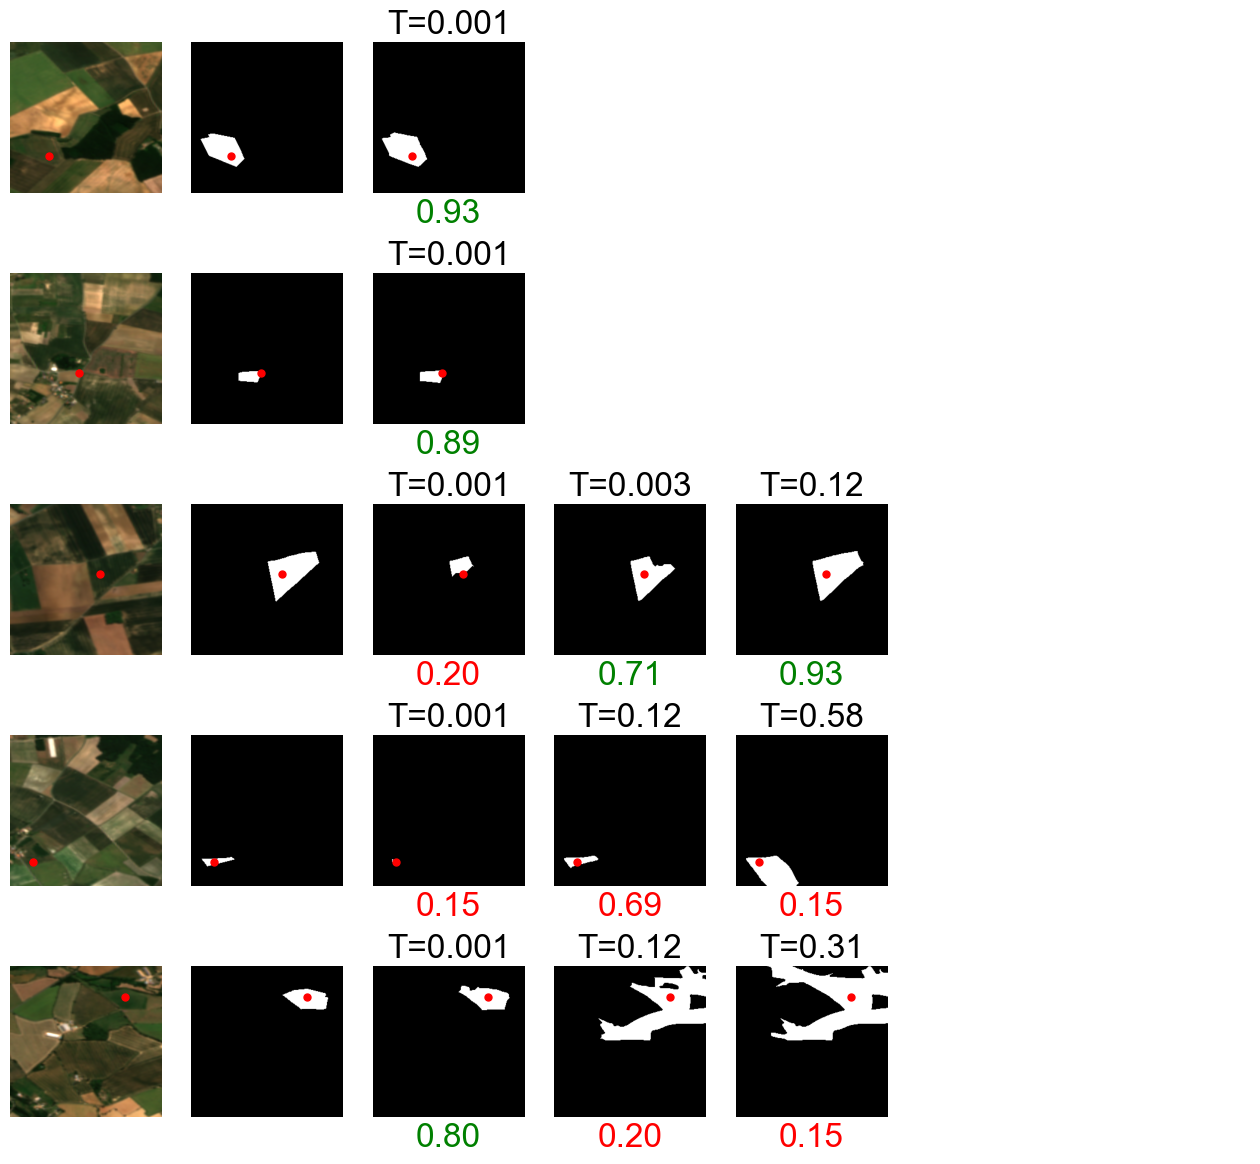

In [19]:
plt.rcParams["font.sans-serif"] = "Arial"
plt.rc('font', size=24) 
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)
plt.rc('figure', titlesize=24)

from skimage.color import label2rgb
np.random.seed(0)

fig, axs = plt.subplots(nrows=5, ncols=7, figsize=(16, 14.5))

i=0
for index, row in results_table_test.sample(n=5).sort_values(by='Final Mask Number', ascending=True).iterrows():
    image_number = row["image_number"]
    coord = row["coord"]
    T_confidence_set_duplicates_removed = T_confidence_set[row["Final Mask Indices"]]

    print(image_number)
    print("MAX IOU:", row["max IOU"])
    print("Final MAX IOU:", row["Final Mask max IOU"])

    rgb_img = rasterio.open(os.path.join('../data/ftw_predictions/france_test/inputs_stacked', image_number+'.tif')).read()
    rgb_img = rgb_img[0:3].transpose(1, 2, 0)/ 3000
    plt.sca(axs[i, 0])
    plt.imshow(np.clip(rgb_img, 0, 1))
    plt.plot(coord[1], coord[0], "o", color="red", markersize=5)
    plt.axis('off')

    #print("True Segmentation")
    true_segmentation = rasterio.open(os.path.join('../data/ftw/france/label_masks/instance', image_number+'.tif')).read()[0]
    plt.sca(axs[i, 1])
    plt.imshow(true_segmentation==true_segmentation[coord[0].item(), coord[1].item()], cmap='gray')
    plt.plot(coord[1], coord[0], "o", color="red", markersize=5)
    plt.axis('off')

    pred_probability = rasterio.open(os.path.join('../data/ftw_predictions/france_test/predictions_3class/probability', image_number+'.tif')).read()[2]
    
    #print("Confidence Set with Duplicates Removed")
    true_field = true_segmentation==true_segmentation[coord]
    for j, pred_segmentation in enumerate(confidence_sets[i]):
        pred_field = pred_segmentation==pred_segmentation[coord]
        IOU = iou(torch.from_numpy(true_field), torch.from_numpy(pred_field)).numpy().item()
        
        plt.sca(axs[i, 2+j])
        plt.imshow(pred_segmentation==pred_segmentation[coord[0].item(), coord[1].item()], cmap='gray')
        plt.plot(coord[1], coord[0], "o", color="red", markersize=5)
        
        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
        if T_confidence_set_duplicates_removed[j] < 0.01:
            plt.title(f"T={T_confidence_set_duplicates_removed[j]:.3f}")
        else:
            plt.title(f"T={T_confidence_set_duplicates_removed[j]:.2f}")

        if IOU > tau:
            plt.xlabel(f"{np.round(IOU, 2):.2f}", color='green')
        else:
            plt.xlabel(f"{np.round(IOU, 2):.2f}", color='red')

    # remove empty grids
    for j in range(2+len(T_confidence_set_duplicates_removed), 7):
        axs[i, j].axis('off')

    i+= 1
    
#plt.tight_layout()
plt.show()